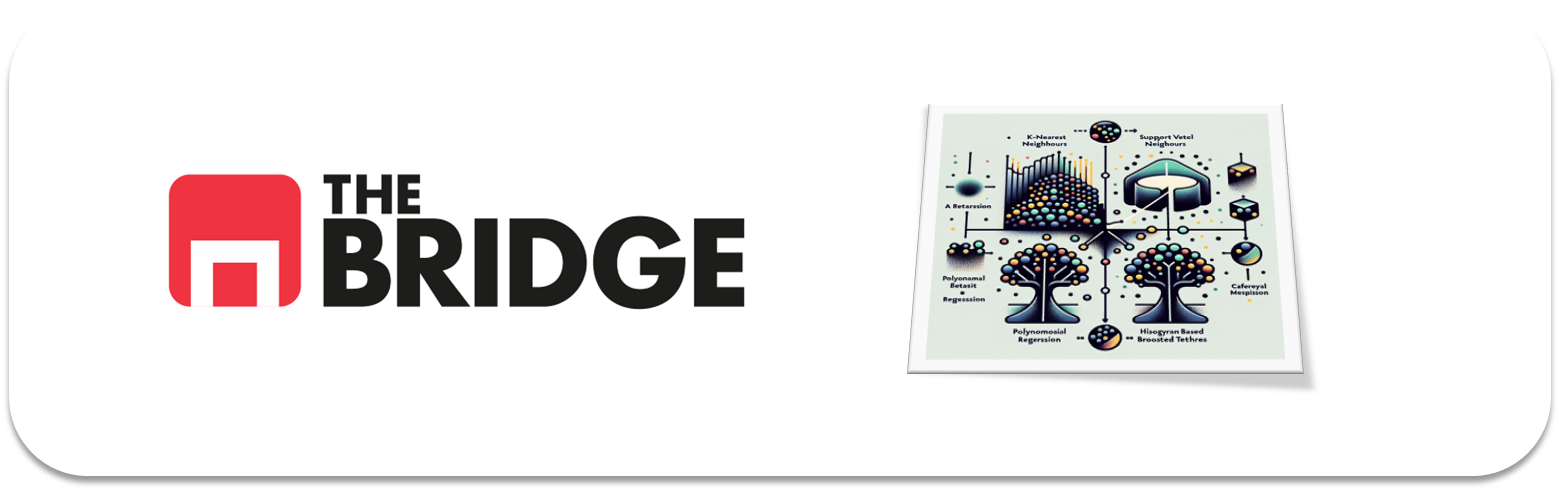

## PRACTICA OBLIGATORIA: **Otros Modelos Supervisados**

* La práctica obligatoria de esta unidad consiste en resolver un modelado de clasificación, incluyendo KNN entre los posibles modelos, y aplicando balanceado. Para ello utilizaremos un dataset que ya hemos empleado en los workout. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [50]:
2+2+2+2

8

In [51]:
#Importamos los paquetes y los módulos:
import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
mpl.rc('axes', labelsize=8)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

### #1. El problema y los datos

Vamos a volver al dataset con el que vimos la clasificación binaria con regresión logística, "Give me some credit", y nuestro objetivo es crear un modelo que nos permita predicir si una persona va a encontrarse en dificultades financieras en los dos próximos años. El dataset de partida lo puedes en contrar en el directorio data que acompaña al ejercicio. 

### #1.1
Cárgalo y, apoyándote en las herramientas y fuentes que consideres necesarias, haz una descripción textual de sus variables. Luego con ayuda de los datos, haz una clasificación inicial de sus variables en categóricas y numéricas.

In [52]:
#Cargamos el dataset ("Give me some credit"):
df=pd.read_csv("./data/credit_npo.csv")

In [53]:
#Echamos un vistazo:
df.head(10)

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.081892,37,0,0.070709,5656.0,12,1,0,0,0.0
1,0,0.023413,74,0,0.209197,4870.0,9,0,1,0,0.0
2,0,0.000000,43,0,0.080784,5000.0,2,0,0,0,2.0
3,0,0.492754,44,0,0.412735,7333.0,4,0,2,0,3.0
4,0,1.000000,63,0,0.000000,8333.0,3,0,0,0,1.0
5,0,0.101002,61,0,0.217115,15880.0,5,0,1,0,0.0
6,0,0.222830,60,0,0.907083,1312.0,5,0,0,0,0.0
7,0,0.353443,39,0,0.764309,4000.0,11,0,1,0,2.0
8,0,0.772455,45,0,0.387179,5100.0,5,0,1,0,3.0
9,0,0.116165,44,0,0.160236,10833.0,8,0,1,0,0.0


In [54]:
#Visualizamos la informacion:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12537 entries, 0 to 12536
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      12537 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  12537 non-null  float64
 2   age                                   12537 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  12537 non-null  int64  
 4   DebtRatio                             12537 non-null  float64
 5   MonthlyIncome                         11816 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       12537 non-null  int64  
 7   NumberOfTimes90DaysLate               12537 non-null  int64  
 8   NumberRealEstateLoansOrLines          12537 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  12537 non-null  int64  
 10  NumberOfDependents                    12360 non-null  float64
dtypes: float64(4), 

**VARIABLES**: <br>
SeriousDlqin2yrs --> 1 si ha tenido retrasos de pago de 90 días o más en los últimos 2 años; 0 si no.  <br>
RevolvingUtilizationOfUnsecuredLines --> Saldo total en tarjetas de crédito y líneas de crédito personales dividido por la suma de los límites de crédito.  <br>
age --> Edad del prestatario en años.<br>
NumberOfTime30-59DaysPastDueNotWorse --> Número de veces que el cliente se ha retrasado entre 30 y 59 días en pagar, pero no peor, en los últimos 2 años.<br>
DebtRatio --> Ratio de deuda: Pagos mensuales de deudas, pensión alimenticia y gastos de subsistencia divididos por los ingresos brutos mensuales.<br>
MonthlyIncome --> Ingresos mensuales. <br>
NumberOfOpenCreditLinesAndLoans --> Número de préstamos abiertos (ej. plazos o hipotecas) y líneas de crédito (ej. tarjetas). <br>
NumberOfTimes90DaysLate --> Número de veces que el cliente ha tenido un retraso de 90 días o más en pagar. <br>
NumberRealEstateLoansOrLines --> Número de préstamos hipotecarios y líneas de crédito con garantía hipotecaria.  Número de veces que el cliente se ha retrasado entre 60 y 89 días en pagar en los últimos 2 años.<br>
NumberOfTime60-89DaysPastDueNotWorse --> Número de veces que el cliente se ha retrasado entre 60 y 89 días en pagar en los últimos 2 años. <br>
NumberOfDependents --> Número de personas a cargo en la familia (excluyendo al propio cliente).<br>

In [55]:
#Comprobamos si el dataset tiene nulos:
df.isna().sum()/len(df)*100
#Tienen nulos MonthlyIncome y NumberofDependets

SeriousDlqin2yrs                        0.000000
RevolvingUtilizationOfUnsecuredLines    0.000000
age                                     0.000000
NumberOfTime30-59DaysPastDueNotWorse    0.000000
DebtRatio                               0.000000
MonthlyIncome                           5.750977
NumberOfOpenCreditLinesAndLoans         0.000000
NumberOfTimes90DaysLate                 0.000000
NumberRealEstateLoansOrLines            0.000000
NumberOfTime60-89DaysPastDueNotWorse    0.000000
NumberOfDependents                      1.411821
dtype: float64

In [56]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,12537.0,0.068916,0.253321,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,12537.0,0.330359,0.368148,0.0,0.030651,0.163490,0.582219,6.0
age,12537.0,52.079445,15.077498,21.0,41.000000,51.000000,62.000000,101.0
NumberOfTime30-59DaysPastDueNotWorse,12537.0,0.409588,4.055787,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,12537.0,1.902253,9.122216,0.0,0.142268,0.302025,0.506725,99.0
MonthlyIncome,11816.0,6864.815420,11855.905437,0.0,3498.750000,5416.000000,8300.000000,702500.0
NumberOfOpenCreditLinesAndLoans,12537.0,8.482332,5.165422,0.0,5.000000,8.000000,11.000000,49.0
NumberOfTimes90DaysLate,12537.0,0.259312,4.035658,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,12537.0,0.999202,1.134325,0.0,0.000000,1.000000,2.000000,19.0
NumberOfTime60-89DaysPastDueNotWorse,12537.0,0.228364,4.018873,0.0,0.000000,0.000000,0.000000,98.0


In [57]:
#Valor 98 es sospechoso
df["NumberOfTime30-59DaysPastDueNotWorse"].value_counts()	

NumberOfTime30-59DaysPastDueNotWorse
0     10500
1      1377
2       401
3       128
4        64
5        23
98       21
6        20
8         2
7         1
Name: count, dtype: int64

In [58]:
df.SeriousDlqin2yrs.value_counts()

SeriousDlqin2yrs
0    11673
1      864
Name: count, dtype: int64

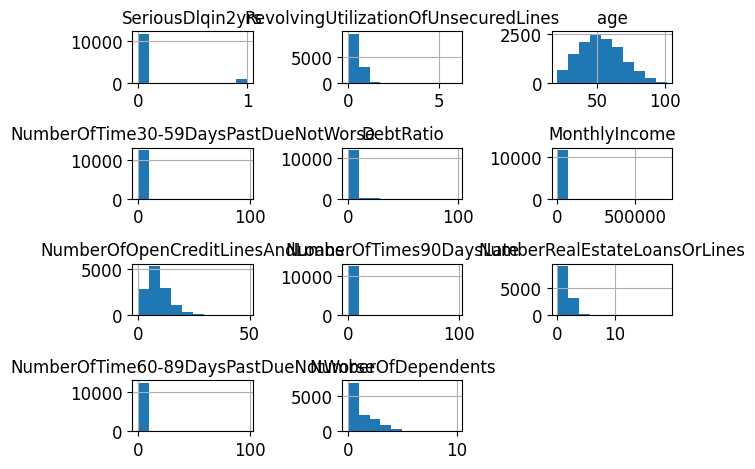

In [59]:
df.hist()
plt.tight_layout()


In [60]:
#Hay que escalar las variables

from sklearn.preprocessing import StandardScaler, MinMaxScaler

escalador=StandardScaler()


In [61]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.utils import resample

### #1.2
¿Qué tipo de problema estamos tratando? ¿Cuál es la variable target?

Es un problema de clasificación. La variable target debe ser SeriousDlqin2yrs

### #1.3
Pinta la distribución de frecuencias del target y coméntala

In [62]:
def describe_df(df):
    DATA_TYPE=df.dtypes
    MISSINGS=(df.isna().sum()/len(df)*100).sort_values(ascending=False)
    UNIQUE_VALUES=df.nunique()
    CARDIN=UNIQUE_VALUES/len(df)*100
    describe_df=pd.DataFrame([DATA_TYPE, MISSINGS, UNIQUE_VALUES, CARDIN])
    parametros=["DATA_TYPE", "MISSINGS (%)", "UNIQUE_VALUES", "CARDIN (%)"]
    describe_df.insert(0, "COL_N",parametros)
    return describe_df

In [63]:
df_describe=describe_df(df).T

In [64]:
df_describe

,0,1,2,3
COL_N,DATA_TYPE,MISSINGS (%),UNIQUE_VALUES,CARDIN (%)
SeriousDlqin2yrs,int64,0.0,2,0.015953
RevolvingUtilizationOfUnsecuredLines,float64,0.0,10764,85.857861
age,int64,0.0,78,0.622158
NumberOfTime30-59DaysPastDueNotWorse,int64,0.0,10,0.079764
DebtRatio,float64,0.0,11547,92.103374
MonthlyIncome,float64,5.750977,4167,33.237617
NumberOfOpenCreditLinesAndLoans,int64,0.0,43,0.342985
NumberOfTimes90DaysLate,int64,0.0,13,0.103693
NumberRealEstateLoansOrLines,int64,0.0,16,0.127622


<Axes: xlabel='SeriousDlqin2yrs', ylabel='count'>

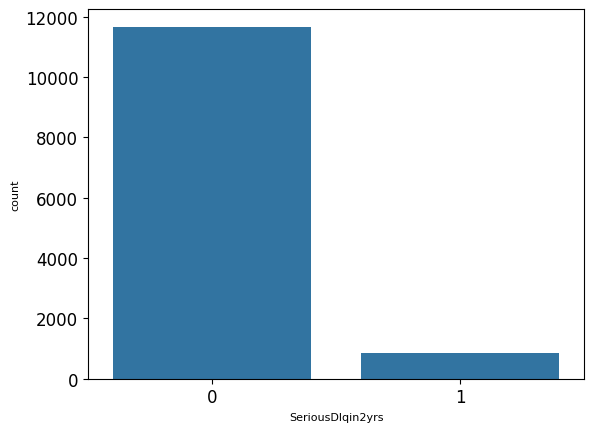

In [65]:
#Dibujamos la distribución de la variable target (esta desequilibrado)
target="SeriousDlqin2yrs"
sns.countplot(data=df, x=target)

In [66]:
df.columns

Index(['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'],
      dtype='object')

In [67]:
#Definimos las variables numéricas (todas excepto NumberOfDependents)
feat_num=df.columns.to_list()

In [68]:
feat_num.remove("SeriousDlqin2yrs")

In [69]:
feat_num

['RevolvingUtilizationOfUnsecuredLines',
 'age',
 'NumberOfTime30-59DaysPastDueNotWorse',
 'DebtRatio',
 'MonthlyIncome',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfTimes90DaysLate',
 'NumberRealEstateLoansOrLines',
 'NumberOfTime60-89DaysPastDueNotWorse',
 'NumberOfDependents']

### #2 Modelado

Realiza un proceso completo de modelado hasta dar con el mejor modelo de los que hayas escogido (emplea al menos 3, y uno tiene que ser KNN). Aplica las técnicas que creas necesarias para obtener el mejor resultado (suponiendo que este después de hablar con el negocio es el recall medio, para tener un compromiso entre las dos clases). Para comparar modelos emplea validación cruzada antes de optimización y luego ajusta los hiperparámetros del mejor modelo. Evalúa este y haz un pequeño análisis de errores.

In [70]:
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [71]:
#Obtenemos datasets de train y test:
#Hay que stratificar (cuando hay datasets grandes sobre todo)
train_set, test_set=train_test_split(df, test_size=0.2, random_state=42, stratify=df["SeriousDlqin2yrs"])

In [72]:
#Imputaciones:
#Mediana para nop y moda mi
nod="NumberOfDependents"
mi="MonthlyIncome"

In [73]:
train_set[nod].quantile(0.5)

np.float64(0.0)

In [74]:
moda_train=train_set[nod].mode()
print(moda_train)

0    0.0
Name: NumberOfDependents, dtype: float64


In [75]:
moda_train=moda_train[0]

train_set[nod]=train_set[nod].fillna(moda_train)
test_set[nod]=test_set[nod].fillna(moda_train)

In [76]:
train_set.isna().sum()

SeriousDlqin2yrs                          0
RevolvingUtilizationOfUnsecuredLines      0
age                                       0
NumberOfTime30-59DaysPastDueNotWorse      0
DebtRatio                                 0
MonthlyIncome                           583
NumberOfOpenCreditLinesAndLoans           0
NumberOfTimes90DaysLate                   0
NumberRealEstateLoansOrLines              0
NumberOfTime60-89DaysPastDueNotWorse      0
NumberOfDependents                        0
dtype: int64

(2,)


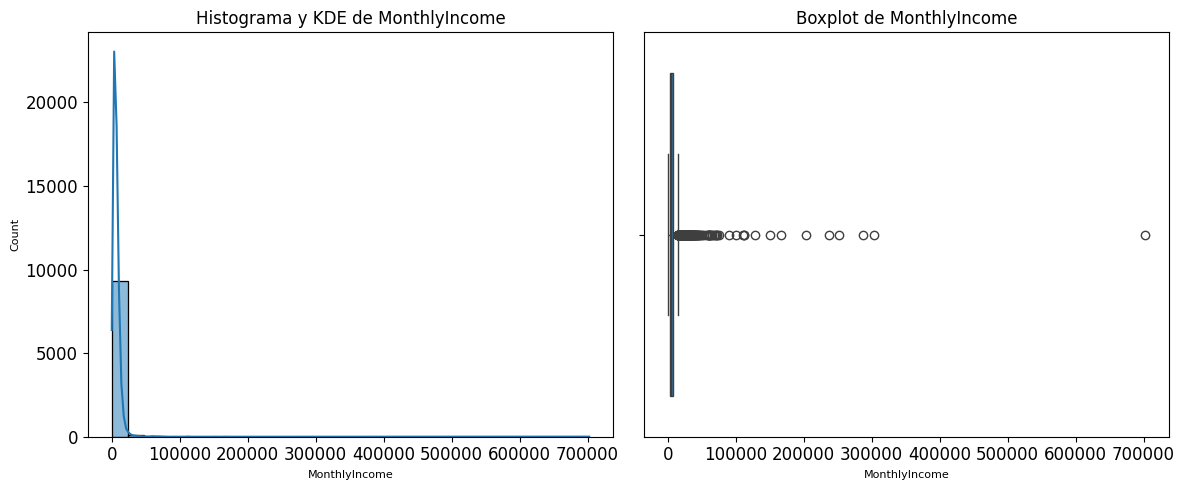

In [77]:
#Dibujamos monthly income:
import bootcampviztools as bt
bt.plot_combined_graphs(train_set, columns=[mi], bins=30)

(2,)


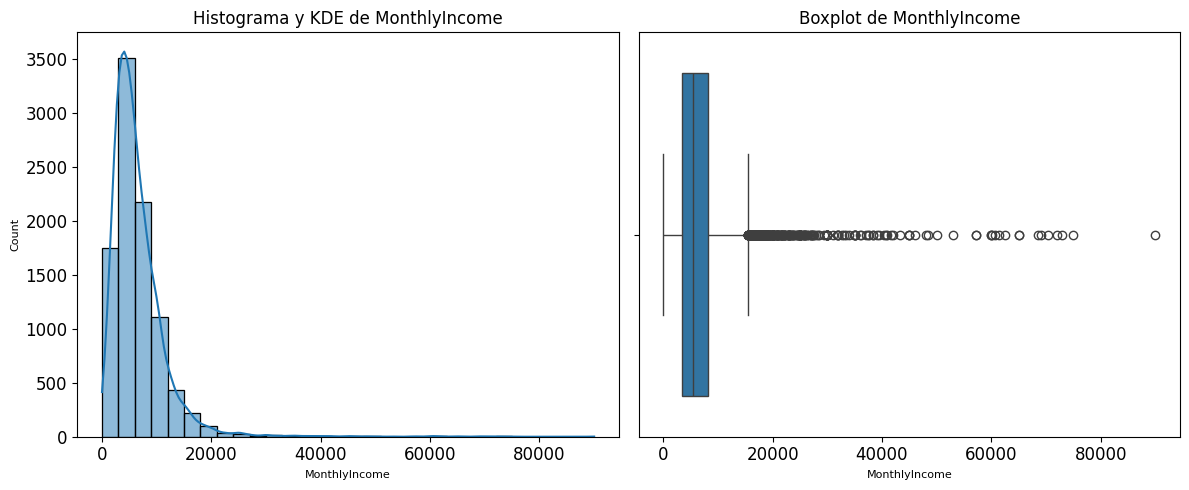

In [78]:
#Salarios por debajo de 100000:
bt.plot_combined_graphs(train_set[train_set[mi] < 100000], columns=[mi], bins=30)

<Axes: xlabel='MonthlyIncome', ylabel='Count'>

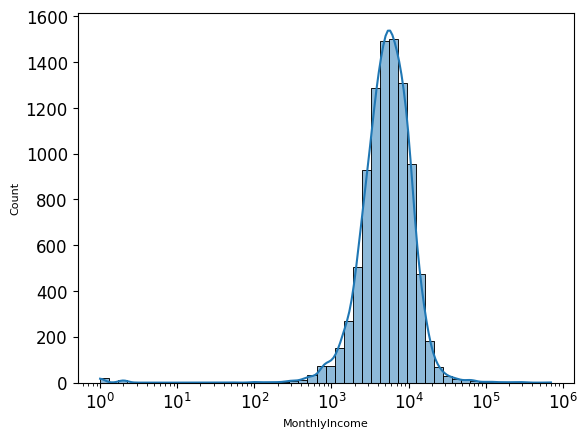

In [79]:
sns.histplot(train_set[mi]+1, bins=50, kde=True, log_scale=10)

In [80]:
mediana=train_set[mi].quantile(0.5)

train_set[mi]=train_set[mi].fillna(mediana)
test_set[mi]=test_set[mi].fillna(mediana)

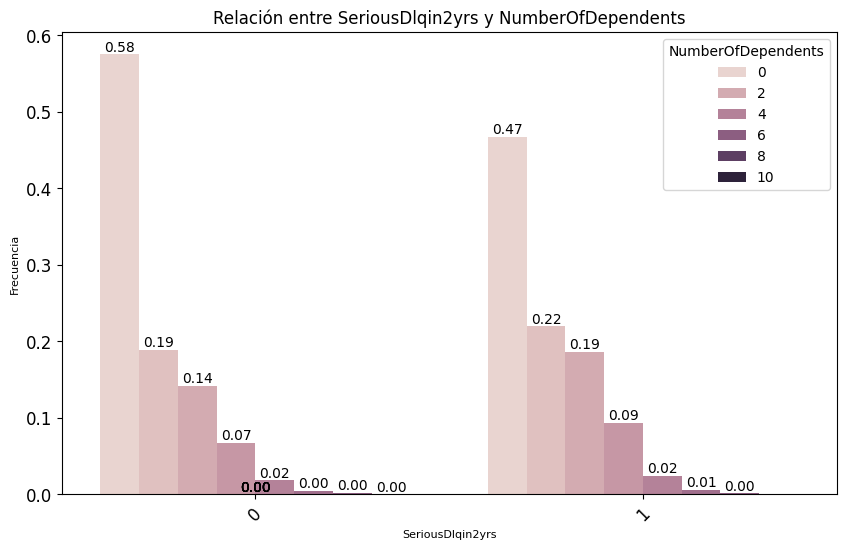

In [81]:
#Relacion de la categórica nod con el target (por la pinta no haría falta incluirla)
bt.plot_categorical_relationship_fin(train_set, target, nod, show_values=True, relative_freq=True)

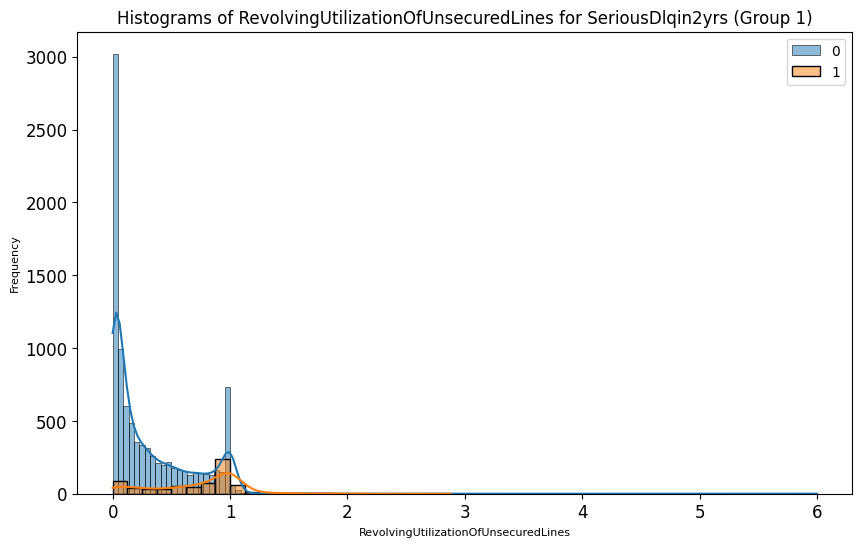

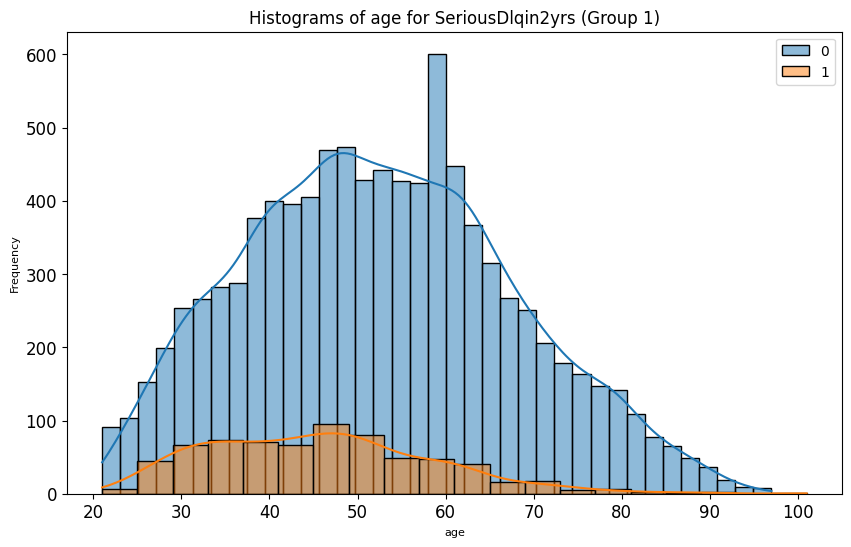

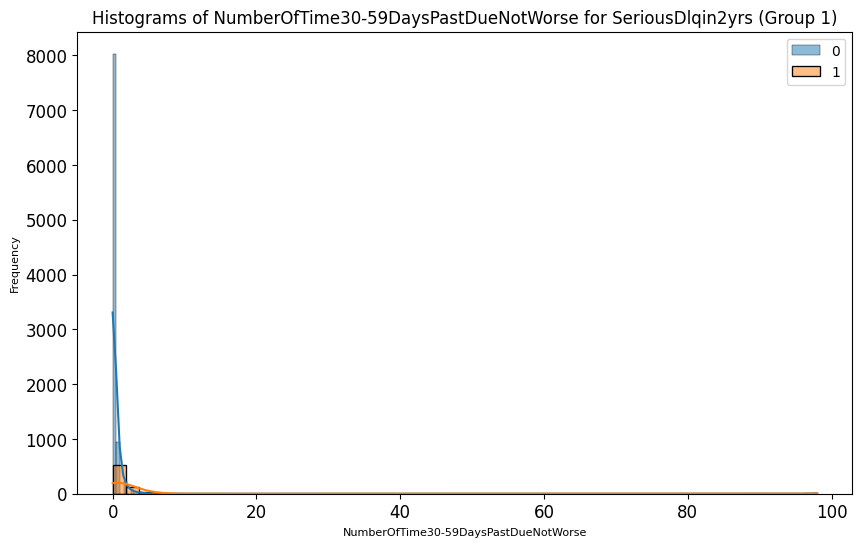

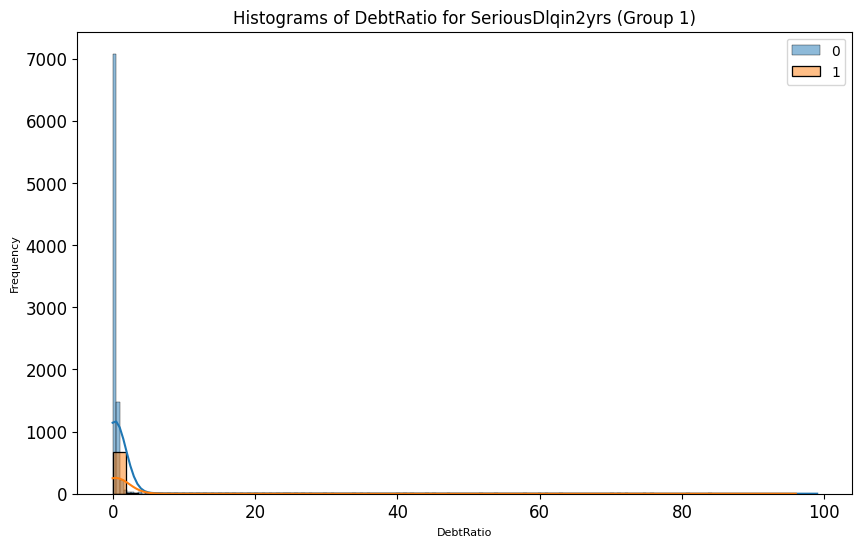

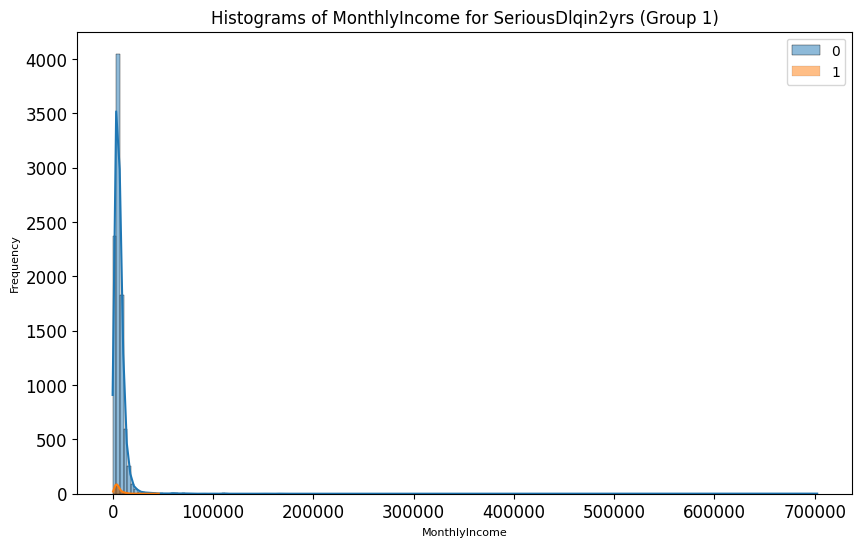

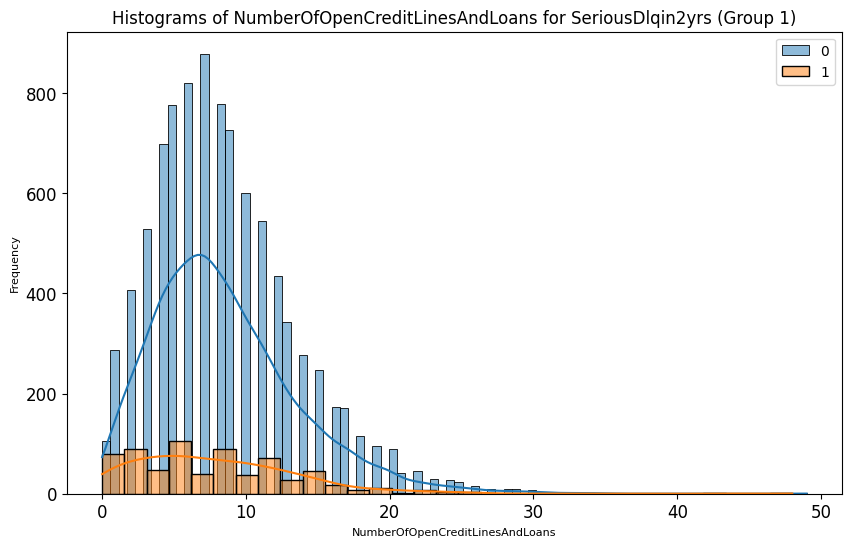

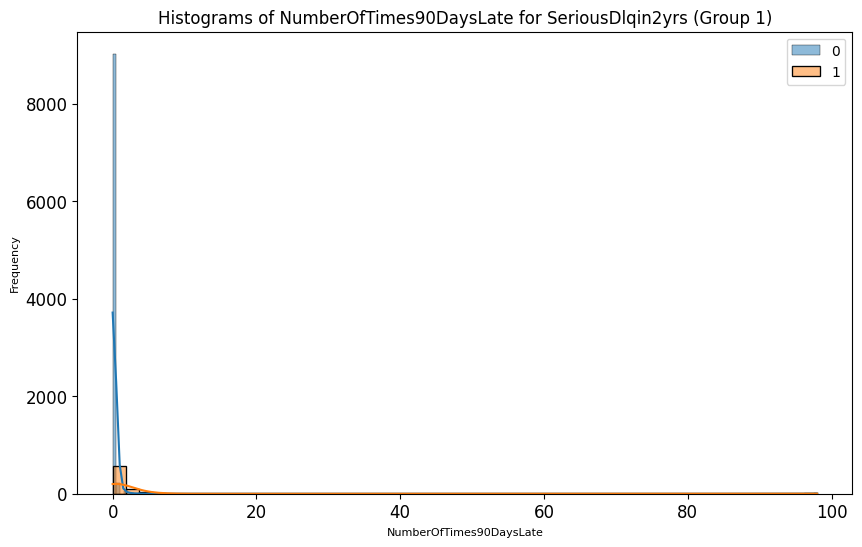

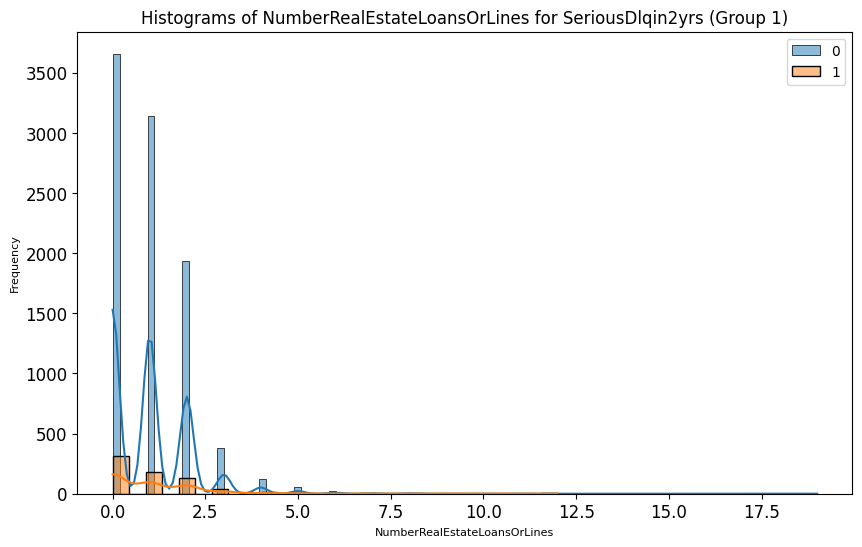

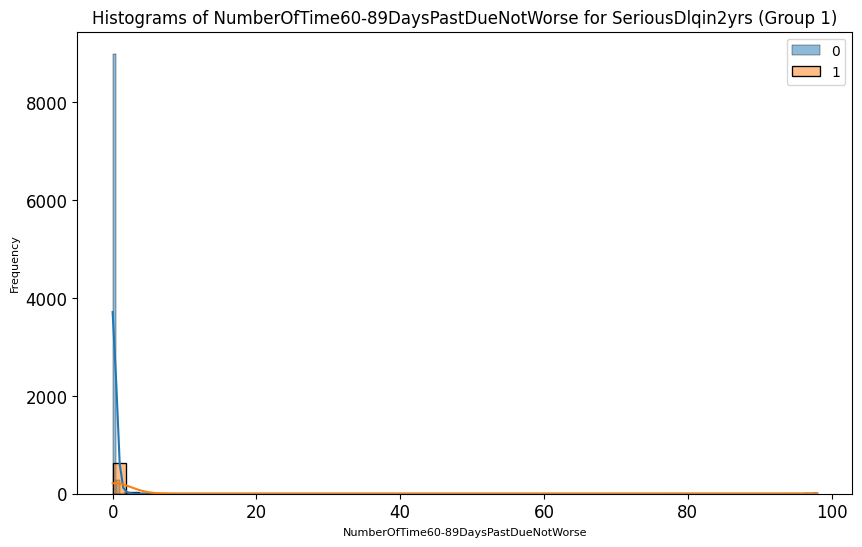

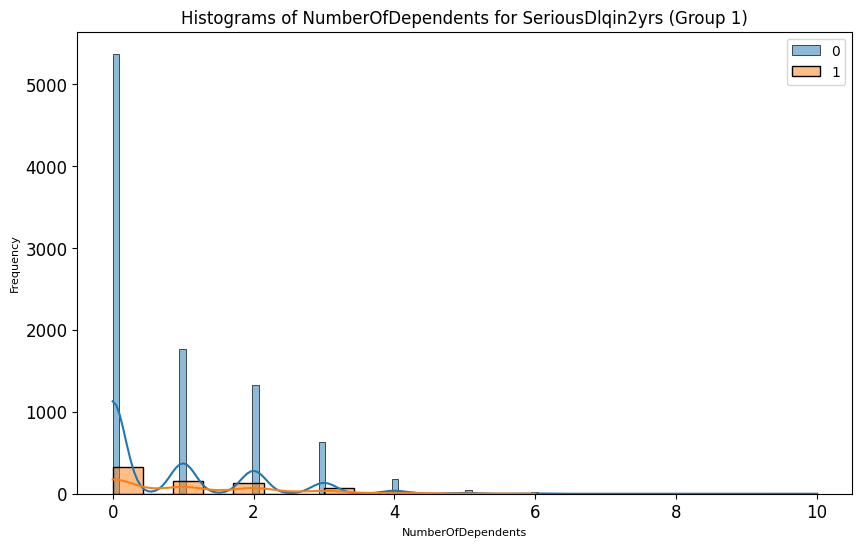

In [82]:
for col in feat_num:
    bt.plot_grouped_histograms(train_set, cat_col=target, num_col=col, group_size=2)

In [83]:
train_set

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
8818,0,0.952783,51,4,0.478968,15000.0,10,0,3,0,4.0
4520,0,1.000000,45,0,0.491605,7027.0,7,0,1,0,0.0
337,0,0.538922,33,0,0.089734,4100.0,3,0,0,0,0.0
12501,0,0.036962,46,0,0.322784,13333.0,7,0,1,0,0.0
8837,0,0.089869,42,1,0.091979,3652.0,3,0,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
12390,0,0.042309,44,0,0.205981,29361.0,11,0,3,0,2.0
10382,0,0.227732,69,0,0.655826,3166.0,8,0,1,0,0.0
5907,0,0.577547,57,0,0.865273,5833.0,13,0,1,0,0.0
2165,0,0.926410,31,0,0.471008,1120.0,3,0,0,0,0.0


In [84]:
#El valor 0 es el que tiene con diferencia la mayor frecuencia
numberOf = [col for col in train_set if col.startswith("NumberOfTime")]
for col in numberOf:
    print(f"Para pagadores, value_counts de {col}")
    print(train_set[train_set[target]== 0][col].value_counts(True))
    print(f"Para impagadores")
    print(train_set[train_set[target]==1][col].value_counts(True))
    print("****")

Para pagadores, value_counts de NumberOfTime30-59DaysPastDueNotWorse
NumberOfTime30-59DaysPastDueNotWorse
0     0.859927
1     0.100236
2     0.025380
3     0.008032
4     0.003641
98    0.000964
5     0.000964
6     0.000750
7     0.000107
Name: proportion, dtype: float64
Para impagadores
NumberOfTime30-59DaysPastDueNotWorse
0     0.529667
1     0.228654
2     0.130246
3     0.046310
4     0.031838
6     0.015919
5     0.010130
98    0.007236
Name: proportion, dtype: float64
****
Para pagadores, value_counts de NumberOfTimes90DaysLate
NumberOfTimes90DaysLate
0     0.966374
1     0.024631
2     0.005462
3     0.001285
98    0.000964
4     0.000535
5     0.000428
6     0.000214
13    0.000107
Name: proportion, dtype: float64
Para impagadores
NumberOfTimes90DaysLate
0     0.662808
1     0.147612
2     0.088278
3     0.039074
4     0.027496
5     0.014472
98    0.007236
6     0.004342
8     0.004342
7     0.004342
Name: proportion, dtype: float64
****
Para pagadores, value_counts de Numbe

In [85]:
df.NumberOfDependents.value_counts()

NumberOfDependents
0.0     6935
1.0     2384
2.0     1816
3.0      882
4.0      253
5.0       62
6.0       24
8.0        2
10.0       1
7.0        1
Name: count, dtype: int64

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

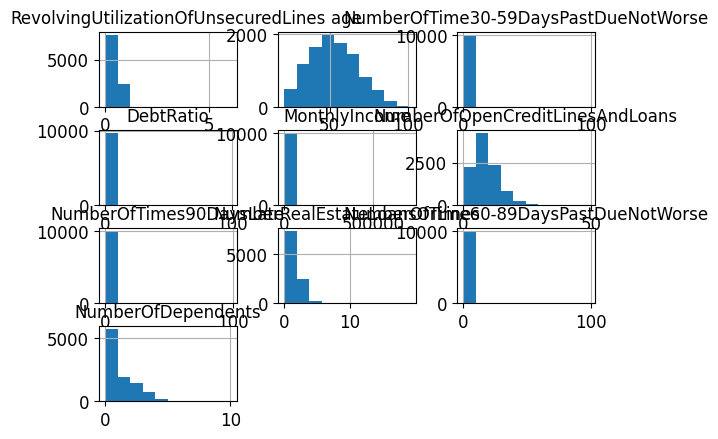

In [86]:
#Tratamiento de features 
train_set[feat_num].hist()
plt.tight_layout

In [87]:
train_set_scaled = train_set.copy()
test_set_scaled = test_set.copy()

In [88]:
#Aplicamos el logaritmo:
for col in feat_num:
    if col != "age":
        train_set_scaled[col] = np.log(train_set_scaled[col] + 1) 
        test_set_scaled[col] = np.log(test_set_scaled[col] + 1) 

In [89]:
feat_num

['RevolvingUtilizationOfUnsecuredLines',
 'age',
 'NumberOfTime30-59DaysPastDueNotWorse',
 'DebtRatio',
 'MonthlyIncome',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfTimes90DaysLate',
 'NumberRealEstateLoansOrLines',
 'NumberOfTime60-89DaysPastDueNotWorse',
 'NumberOfDependents']

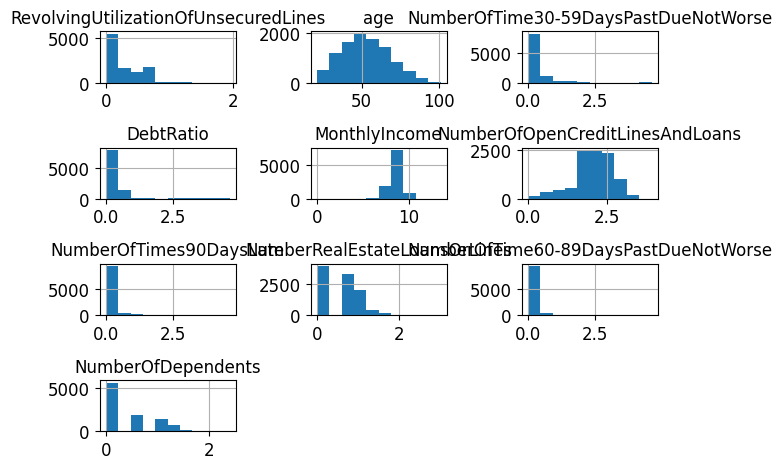

In [90]:
train_set_scaled[feat_num].hist()
plt.tight_layout()

In [91]:
feat_num

['RevolvingUtilizationOfUnsecuredLines',
 'age',
 'NumberOfTime30-59DaysPastDueNotWorse',
 'DebtRatio',
 'MonthlyIncome',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfTimes90DaysLate',
 'NumberRealEstateLoansOrLines',
 'NumberOfTime60-89DaysPastDueNotWorse',
 'NumberOfDependents']

In [94]:
#Escalamos las variables:
from sklearn.preprocessing import StandardScaler
escalador=StandardScaler()

train_set_scaled[feat_num]=escalador.fit_transform(train_set_scaled[feat_num])
test_set_scaled[feat_num]=escalador.transform(test_set_scaled[feat_num])

Generamos X,y

In [96]:
#Generamos los juegos de X,y
#Juegos de train:
X_train=train_set[feat_num]
X_train_scaled=train_set_scaled[feat_num]
y_train=train_set[target]
#Juegos de set:
X_test=train_set[feat_num]
X_test_scaled=train_set_scaled[feat_num]
y_test=train_set[target]

In [97]:
X_train_scaled.describe()

,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,1.002900e+04,1.002900e+04,1.002900e+04,1.002900e+04,1.002900e+04,1.002900e+04,1.002900e+04,1.002900e+04,1.002900e+04,1.002900e+04
mean,-7.226579e-17,-5.685617e-17,3.896685e-17,-9.918834e-18,8.700234e-16,-1.445316e-16,-2.267162e-17,6.518091e-17,-3.542441e-18,-3.329894e-17
std,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00
min,-9.997589e-01,-2.058956e+00,-3.870193e-01,-6.077475e-01,-1.017112e+01,-3.427721e+00,-1.985685e-01,-1.101964e+00,-1.854473e-01,-8.064883e-01
25%,-8.812348e-01,-7.331305e-01,-3.870193e-01,-4.128377e-01,-4.364605e-01,-4.870781e-01,-1.985685e-01,-1.101964e+00,-1.854473e-01,-8.064883e-01
50%,-3.998107e-01,-7.021760e-02,-3.870193e-01,-2.186041e-01,7.066479e-02,1.783729e-01,-1.985685e-01,2.688619e-01,-1.854473e-01,-8.064883e-01
75%,8.261956e-01,6.589866e-01,-3.870193e-01,-6.233796e-03,5.352929e-01,6.505178e-01,-1.985685e-01,1.070744e+00,-1.854473e-01,4.871155e-01
max,6.720946e+00,3.244347e+00,1.161444e+01,6.144741e+00,5.866365e+00,2.992707e+00,1.612848e+01,4.822648e+00,1.829044e+01,3.668645e+00


In [99]:
#K debe ser impar para evitar el empate

In [102]:
from  sklearn.ensemble import RandomForestClassifier
from  sklearn.linear_model import LogisticRegression
from  sklearn.neighbors import KNeighborsClassifier
from  xgboost import XGBClassifier
from  sklearn.neighbors import KNeighborsClassifier
from lightgbm import LGBMClassifier

In [100]:
knn=KNeighborsClassifier(n_neighbors=7)

knn.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",7
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [ ]:
print(classification_report(y_train, knn.predict(X_train_scaled))) #No utilizamos el test. El valor macro  de recall es muy bajos!


              precision    recall  f1-score   support

           0       0.95      0.99      0.97      9338
           1       0.69      0.23      0.34       691

    accuracy                           0.94     10029
   macro avg       0.82      0.61      0.66     10029
weighted avg       0.93      0.94      0.93     10029



In [103]:
modelos = ["KNN","Logistic","RandomF","XGBoost","LightGBM"]
metricas = []
#Parametros base: random state y max_depth 
lr_clf = LogisticRegression(max_iter = 10000)
rf_clf = RandomForestClassifier(max_depth = 5, random_state = 42)
xgb_clf = XGBClassifier(max_depth = 5, random_state = 42)
lgb_clf = LGBMClassifier(max_depth= 5, random_state = 42, verbose = -1, n_jobs= -1) #verbose para que no pinte todo
#n_jobs es la paralelización del trabajo. Cuantos recursos vamos a utilizar para que este proceso se haga. Optimiza el tiempo de computación.
for nombre, modelo in zip(modelos,[knn, lr_clf, rf_clf, xgb_clf, lgb_clf]):
    print(f"Para {nombre}:", end = " ")
    if nombre not in modelos[0:2]:
        metrica = np.mean(cross_val_score(modelo, X_train, y_train, cv = 5, scoring = "balanced_accuracy")) 
    else:
        metrica = np.mean(cross_val_score(modelo, X_train_scaled, y_train, cv = 5, scoring = "balanced_accuracy"))
    print(metrica)
    metricas.append(metrica)

Para KNN: 0.5738809143505257
Para Logistic: 0.5621148954635444
Para RandomF: 0.5530236484401414
Para XGBoost: 0.5981654200139266
Para LightGBM: 0.5940385606477767


Los resultados son malos teniendo en cuenta el modelo base (KNN) y ssabemos que se debe al desequilibrio del dataset.

In [105]:
#Oversampling con SMOTE (creación sinética de datos):
smote=SMOTE(random_state=42)

X_train_smote, y_train_smote=smote.fit_resample(X_train, y_train)

X_train_smote_scaled, y_train_smote_scaled=smote.fit_resample(X_train_scaled, y_train)

In [106]:
print(len(y_train))
print(len(y_train_smote))

10029
18676


In [108]:
modelos = ["KNN","Logistic","RandomF","XGBoost","LightGBM"]
metricas = []
#Parametros base: random state y max_depth 
lr_clf = LogisticRegression(max_iter = 10000)
rf_clf = RandomForestClassifier(max_depth = 5, random_state = 42)
xgb_clf = XGBClassifier(max_depth = 5, random_state = 42)
lgb_clf = LGBMClassifier(max_depth= 5, random_state = 42, verbose = -1, n_jobs= -1) #verbose para que no pinte todo
#n_jobs es la paralelización del trabajo. Cuantos recursos vamos a utilizar para que este proceso se haga. Optimiza el tiempo de computación.
for nombre, modelo in zip(modelos,[knn, lr_clf, rf_clf, xgb_clf, lgb_clf]):
    print(f"Para {nombre}:", end = " ")
    if nombre not in modelos[0:2]:
        metrica = np.mean(cross_val_score(modelo, X_train_smote, y_train_smote, cv = 5, scoring = "balanced_accuracy")) 
    else:
        metrica = np.mean(cross_val_score(modelo, X_train_smote_scaled, y_train_smote_scaled, cv = 5, scoring = "balanced_accuracy"))
    print(metrica)
    metricas.append(metrica)

Para KNN: 0.895588744668186
Para Logistic: 0.7820205611035349
Para RandomF: 0.8167712862531813
Para XGBoost: 0.9142799427450055
Para LightGBM: 0.8993409998291068


In [109]:
#Undersampling con resample

#Separamos las clases:
clase_mayoritaria = X_train[y_train == 0]
clase_minoritaria = X_train[y_train == 1]

clase_mayoritaria_scaled = X_train_scaled[y_train == 0]
clase_minoritaria_scaled = X_train_scaled[y_train == 1]


In [110]:
# Bajomuestrear la clase mayoritaria para no escalado
clase_mayoritaria_bajomuestreo = resample(clase_mayoritaria,
                                          replace=False,
                                          n_samples=len(clase_minoritaria),  # igual al número de la clase minoritaria
                                          random_state=42)

# Combinar la clase minoritaria con la clase mayoritaria bajomuestreada (importante es que resample mantiene los índices para que lo que viene a continuación tenga sentido)
X_train_bajomuestreo = pd.concat([clase_mayoritaria_bajomuestreo, clase_minoritaria])
y_train_bajomuestreo = pd.concat([y_train.loc[clase_mayoritaria_bajomuestreo.index], 
                                  y_train.loc[clase_minoritaria.index]])


In [111]:
# Bajomuestrear la clase mayoritaria para escalado
clase_mayoritaria_bajomuestreo_scl = resample(clase_mayoritaria_scaled,
                                          replace=False,
                                          n_samples=len(clase_minoritaria_scaled),  # igual al número de la clase minoritaria
                                          random_state=42)

# Combinar la clase minoritaria con la clase mayoritaria bajomuestreada (importante es que resample mantiene los índices para que lo que viene a continuación tenga sentido)
X_train_bajomuestreo_scl = pd.concat([clase_mayoritaria_bajomuestreo_scl, clase_minoritaria_scaled])
y_train_bajomuestreo_scl = pd.concat([y_train.loc[clase_mayoritaria_bajomuestreo_scl.index], 
                                  y_train.loc[clase_minoritaria_scaled.index]])


In [ ]:
#Ajustamos los modelos con undersmapling:
modelos = ["KNN","Logistic","RandomF","XGBoost","LightGBM"]
metricas = []
lr_clf = LogisticRegression(max_iter = 10000)
rf_clf = RandomForestClassifier(max_depth = 5, random_state = 42)
xgb_clf = XGBClassifier(max_depth = 5, random_state = 42)
lgb_clf = LGBMClassifier(max_depth= 5, verbose = -1, random_state = 42, n_jobs= -1)
model = []

for nombre,modelo in zip(modelos,[knn, lr_clf, rf_clf, xgb_clf, lgb_clf]):
    model.append(modelo)
    print(f"Para {nombre}:", end = " ")
    if nombre not in modelos[0:2]:
        metrica = np.mean(cross_val_score(modelo, X_train_bajomuestreo, y_train_bajomuestreo, cv = 5, scoring = "balanced_accuracy"))
    else:
        metrica = np.mean(cross_val_score(modelo, X_train_bajomuestreo_scl, y_train_bajomuestreo_scl, cv = 5, scoring = "balanced_accuracy"))
    print(metrica)
    metricas.append(metrica)

Para KNN: 0.756162026900219
Para Logistic: 0.7720779897820874
Para RandomF: 0.7655979564174747
Para XGBoost: 0.7366541549369201
Para LightGBM: 0.7482327181732875


In [ ]:
#Ajustamos los modelos con el hiperparámetro class-weight
modelos = ["KNN","Logistic","RandomF","XGBoost","LightGBM"]
metricas = []

knn_clf = KNeighborsClassifier(n_neighbors= 7, weights= "distance")
lr_clf = LogisticRegression(max_iter = 10000, class_weight= "balanced")
rf_clf = RandomForestClassifier(max_depth = 5, random_state = 42, class_weight= "balanced")
xgb_clf = XGBClassifier(max_depth = 5, random_state = 42, scale_pos_weight = len(train_set[train_set[target] == 0])/len(train_set[target] == 1))
lgb_clf = LGBMClassifier(max_depth= 5, verbose = -100, random_state = 42, class_weight= "balanced", n_jobs=-1)

for nombre,modelo in zip(modelos,[knn_clf, lr_clf, rf_clf, xgb_clf, lgb_clf]):
    print(f"Para {nombre}:", end = " ")
    if nombre not in modelos[0:2]:
        metrica = np.mean(cross_val_score(modelo, X_train, y_train, cv = 5, scoring = "balanced_accuracy"))
    else:
        metrica = np.mean(cross_val_score(modelo, X_train_scaled, y_train, cv = 5, scoring = "balanced_accuracy"))
    print(metrica)
    metricas.append(metrica)

Para KNN: 0.5747895872395858
Para Logistic: 0.7722222977677402
Para RandomF: 0.764310223682256
Para XGBoost: 0.5875349579126563
Para LightGBM: 0.7441822823703934


In [114]:
### LightGBM (tarda mucho)

param_grid = {
    "n_estimators": [100,200],
    "learning_rate": [0.1,0.5,1],
    "max_depth": [5,10,15],
    "min_data_in_leaf": [1,10,20,100],
    "class_weight": ["balanced",None]
}

lgb_clf = LGBMClassifier(verbose = -1)

lgb_grid = GridSearchCV(lgb_clf,
                        param_grid= param_grid,
                        cv = 5,
                        scoring= "balanced_accuracy",
                        n_jobs=-1)

lgb_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LGBMClassifier(verbose=-1)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': ['balanced', None], 'learning_rate': [0.1, 0.5, ...], 'max_depth': [5, 10, ...], 'min_data_in_leaf': [1, 10, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for

In [115]:
lgb_grid.best_params_

{'class_weight': 'balanced',
 'learning_rate': 0.1,
 'max_depth': 5,
 'min_data_in_leaf': 100,
 'n_estimators': 100}

In [116]:
lgb_grid.best_score_

np.float64(0.7558565094768038)

In [117]:
print(classification_report(y_test, lgb_grid.best_estimator_.predict(X_test)))

              precision    recall  f1-score   support

           0       0.99      0.83      0.91      9338
           1       0.28      0.88      0.43       691

    accuracy                           0.84     10029
   macro avg       0.64      0.86      0.67     10029
weighted avg       0.94      0.84      0.87     10029

